In [1]:
!pip install catboost  # установка библиотеки CatBoost (если не установлена)

import pandas as pd
import numpy as np

# Фиксируем случайное состояние для воспроизводимости результатов
np.random.seed(42)

# Загрузка данных из CSV файла (замените 'data.csv' на путь к вашему файлу, если необходимо)
df = pd.read_csv('data.csv', sep=';', decimal=',', parse_dates=['Datetime'], encoding='cp1251')

# Переименуем колонки для удобства (убираем единицы измерения и специальные символы)
df.columns = ['Datetime', 'Radon', 'Temperature', 'Pressure']

# Убедимся, что данные отсортированы по времени
df.sort_values('Datetime', inplace=True)
df.reset_index(drop=True, inplace=True)

# Посмотрим базовую информацию о наборе данных
print("Количество записей в исходном датасете:", len(df))
print(df.head(5))  # вывод первых 5 строк для ознакомления
print("Пропущенных значений до обработки:")
print(df.isna().sum())  # проверяем наличие пропусков по столбцам

# Преобразуем колонку Datetime к формату datetime (если это не сделано при чтении)
if not np.issubdtype(df['Datetime'].dtype, np.datetime64):
    df['Datetime'] = pd.to_datetime(df['Datetime'], dayfirst=True, errors='raise')

# Устанавливаем временной индекс для интерполяции по времени
df.set_index('Datetime', inplace=True)

# Заполнение пропусков в числовых данных: линейная интерполяция по времени
cols_to_interp = ['Radon', 'Temperature', 'Pressure']
df[cols_to_interp] = df[cols_to_interp].interpolate(method='time')

# Если после интерполяции остаются NaN (например, в начале или конце серии) – заполним ближайшими известными значениями
df[cols_to_interp] = df[cols_to_interp].fillna(method='bfill').fillna(method='ffill')

# Вернем Datetime из индекса в колонку (для дальнейшего использования)
df.reset_index(inplace=True)

# Проверим снова наличие пропусков после заполнения
print("Пропущенных значений после обработки:")
print(df.isna().sum())

# Обработка выбросов (неадекватно больших/малых значений) с помощью метода межквартильного размаха (IQR)
for col in cols_to_interp:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Ограничиваем значения столбца col заданным диапазоном [lower_bound, upper_bound]
    df[col] = df[col].clip(lower_bound, upper_bound)

# Выведем диапазон значений после обработки выбросов, для контроля
print("Диапазон значений после удаления выбросов:")
print(df[cols_to_interp].describe().loc[['min', 'max']])


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00
Количество записей в исходном датасете: 8762
           Datetime    Radon  Temperature    Pressure
0   01.01.2021 0:00  30849.0     1.970866  994.455951
1  01.01.2021 10:00  29436.0     1.949401  996.318096
2  01.01.2021 11:00  25934.0     1.927937  995.993886
3  01.01.2021 12:00  25877.0     1.906476  996.505640
4  01.01.2021 13:00  20905.0     1.901936  996.633681
Пропущенных значений до обработки:
Datetime        0
Radon           9
Temperature    55
Pressure        0
dtype: int64
Пропущенных значений после обработки:
Datetime       0
Radon          0
Temperature    0
Pressure       0
dtype: int64
Диапазон значений после удаления выбросов:
       Radon  Temperature     Pressure
min    508.0    -1.354161   958.782100
max  38533.0     8.338097  1011.087849


<ipython-input-1-f6f19c729bc9>:37: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[cols_to_interp] = df[cols_to_interp].fillna(method='bfill').fillna(method='ffill')


In [2]:
# Создание дополнительных признаков на основе временных рядов
# Градиенты (разности) радона: изменение концентрации за 1 шаг и за ~сутки
df['radon_diff1'] = df['Radon'].diff(periods=1)     # разность радона за один шаг измерения
df['radon_diff17'] = df['Radon'].diff(periods=17)   # разность радона примерно за сутки (17 шагов ~ 24 часа при шаге ~85 мин)

# Скользящие средние (moving averages) для радона на разных окнах
df['radon_ma3'] = df['Radon'].rolling(window=3).mean()    # среднее за 3 измерения (~4.25 часа)
df['radon_ma6'] = df['Radon'].rolling(window=6).mean()    # среднее за 6 измерений (~8.5 часов)
df['radon_ma17'] = df['Radon'].rolling(window=17).mean()  # среднее за ~17 измерений (≈24 часа)
df['radon_ma34'] = df['Radon'].rolling(window=34).mean()  # среднее за ~34 измерения (≈48 часов, ~2 суток)

# Календарные признаки (дата-время): месяц, час суток, день недели
df['month'] = df['Datetime'].dt.month            # месяц (1-12)
df['hour'] = df['Datetime'].dt.hour              # час суток (0-23)
df['day_of_week'] = df['Datetime'].dt.weekday    # день недели (0 = понедельник, ..., 6 = воскресенье)

# После генерации новых признаков могут появиться пропуски (NaN) в начале ряда из-за diff/rolling.
# Заполним их ближайшими следующими значениями (backfill), чтобы не потерять эти строки.
df.fillna(method='bfill', inplace=True)

print("Признаки сгенерированы. Теперь колонки данных:")
print(df.columns.tolist())


Признаки сгенерированы. Теперь колонки данных:
['Datetime', 'Radon', 'Temperature', 'Pressure', 'radon_diff1', 'radon_diff17', 'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34', 'month', 'hour', 'day_of_week']


<ipython-input-2-51ea306511b7>:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill', inplace=True)


In [3]:
# Определяем горизонт прогноза и длину исторической последовательности для нейросети
HORIZON_STEPS = 51    # горизонт прогноза: 51 шаг вперед (~3 дня)
SEQ_LENGTH   = 68     # длина входной последовательности для нейросети (например, 68 шагов ≈ 4 суток истории)

# Список индексов, которые могут быть использованы как целевые (учитывая горизонт и длину истории)
total_points = len(df)
start_index = HORIZON_STEPS + SEQ_LENGTH - 1  # самый ранний индекс, на котором можно сделать прогноз
if start_index >= total_points:
    raise ValueError("Недостаточно данных для выбранных HORIZON_STEPS и SEQ_LENGTH.")
target_indices = list(range(start_index, total_points))
total_samples = len(target_indices)
print(f"Общее количество доступных образцов для моделирования: {total_samples}")

# Разделим данные на обучающую, валидационную и тестовую части по времени (например, 70% / 15% / 15% от последовательных образцов)
train_size = int(0.70 * total_samples)
val_size   = int(0.15 * total_samples)
test_size  = total_samples - train_size - val_size

train_idx = target_indices[:train_size]
val_idx   = target_indices[train_size: train_size + val_size]
test_idx  = target_indices[train_size + val_size:]

print(f"Размер обучающей выборки: {len(train_idx)} примеров")
print(f"Размер валидационной выборки: {len(val_idx)} примеров")
print(f"Размер тестовой выборки: {len(test_idx)} примеров")


Общее количество доступных образцов для моделирования: 8644
Размер обучающей выборки: 6050 примеров
Размер валидационной выборки: 1296 примеров
Размер тестовой выборки: 1298 примеров


In [4]:
# Определяем, какие признаки использовать в качестве "табличных" для модели CatBoost (значения на момент времени i)
xgb_features = ['Radon', 'Temperature', 'Pressure',
                'radon_diff1', 'radon_diff17',
                'radon_ma3', 'radon_ma6', 'radon_ma17', 'radon_ma34',
                'month', 'hour', 'day_of_week']

# Инициализируем списки для данных
X_train_tab, X_val_tab, X_test_tab = [], [], []   # табличные признаки для CatBoost
X_train_seq, X_val_seq, X_test_seq = [], [], []   # последовательности для нейросети
y_train, y_val, y_test = [], [], []               # целевой признак (радон через горизонт)

# Заполняем списки данными для каждого набора (train, val, test)
for idx_list, X_tab_list, X_seq_list, y_list in [
    (train_idx, X_train_tab, X_train_seq, y_train),
    (val_idx,   X_val_tab,   X_val_seq,   y_val),
    (test_idx,  X_test_tab,  X_test_seq,  y_test)
]:
    for j in idx_list:
        # i - индекс времени текущего момента, от которого делается прогноз через горизонт
        i = j - HORIZON_STEPS
        # Табличные признаки на момент времени i
        X_tab_list.append(df.loc[i, xgb_features].values.astype(float))
        # Последовательность значений (Radon, Temperature, Pressure) за предыдущие SEQ_LENGTH шагов [i-SEQ_LENGTH+1 ... i]
        seq_start = i - SEQ_LENGTH + 1
        seq_slice = df.loc[seq_start: i, ['Radon', 'Temperature', 'Pressure']].values.astype(float)
        X_seq_list.append(seq_slice)
        # Целевое значение: концентрация радона на шаге j (через горизонт HORIZON_STEPS от i)
        y_list.append(df.loc[j, 'Radon'])

# Преобразуем списки в numpy-массивы для удобства обучения моделей
X_train_tab = np.array(X_train_tab)
X_val_tab   = np.array(X_val_tab)
X_test_tab  = np.array(X_test_tab)

X_train_seq = np.array(X_train_seq)
X_val_seq   = np.array(X_val_seq)
X_test_seq  = np.array(X_test_seq)

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

# Выведем размеры полученных массивов, чтобы убедиться в корректности формирования выборок
print("Форматы массивов:")
print("X_train_tab:", X_train_tab.shape, "| X_train_seq:", X_train_seq.shape, "| y_train:", y_train.shape)
print("X_val_tab:  ", X_val_tab.shape,   "| X_val_seq:  ", X_val_seq.shape,   "| y_val:  ", y_val.shape)
print("X_test_tab: ", X_test_tab.shape,  "| X_test_seq: ", X_test_seq.shape,  "| y_test: ", y_test.shape)


Форматы массивов:
X_train_tab: (6050, 12) | X_train_seq: (6050, 68, 3) | y_train: (6050,)
X_val_tab:   (1296, 12) | X_val_seq:   (1296, 68, 3) | y_val:   (1296,)
X_test_tab:  (1298, 12) | X_test_seq:  (1298, 68, 3) | y_test:  (1298,)


In [5]:
from sklearn.preprocessing import StandardScaler

# Инициализируем стандартизатор (StandardScaler) для масштабирования входных последовательностей (Radon, Temperature, Pressure)
scaler = StandardScaler()

# Обучаем scaler на обучающей выборке (все последовательности обучающей выборки, объединенные по временной оси)
X_train_seq_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])  # преобразуем в 2D массив [samples*seq_length, features]
scaler.fit(X_train_seq_flat)

# Применяем преобразование нормализации к последовательностям train/val/test
X_train_seq_scaled = scaler.transform(X_train_seq_flat).reshape(X_train_seq.shape)
X_val_seq_scaled   = scaler.transform(X_val_seq.reshape(-1, X_val_seq.shape[-1])).reshape(X_val_seq.shape)
X_test_seq_scaled  = scaler.transform(X_test_seq.reshape(-1, X_test_seq.shape[-1])).reshape(X_test_seq.shape)

# Заменяем исходные последовательности на масштабированные версии
X_train_seq = X_train_seq_scaled
X_val_seq   = X_val_seq_scaled
X_test_seq  = X_test_seq_scaled

print("Масштабирование признаков для последовательностей выполнено.")


Масштабирование признаков для последовательностей выполнено.


In [6]:
from catboost import CatBoostRegressor

# Инициализируем модель CatBoostRegressor с некоторыми гиперпараметрами
cat_model = CatBoostRegressor(
    iterations=1000,           # максимальное количество деревьев
    learning_rate=0.05,        # скорость обучения
    depth=5,                   # максимальная глубина деревьев
    loss_function='RMSE',      # функция потерь (RMSE для регрессии)
    random_seed=42,
    verbose=False
)

# Обучаем CatBoost на обучающих данных, используя валидационную выборку для ранней остановки
cat_model.fit(
    X_train_tab, y_train,
    eval_set=(X_val_tab, y_val),
    early_stopping_rounds=50,
    verbose=100  # выводим прогресс каждые 100 итераций (можно поставить False для отключения вывода)
)

print("CatBoost: обучение завершено. Использовано деревьев:", cat_model.tree_count_)


0:	learn: 8516.4114470	test: 8104.0520498	best: 8104.0520498 (0)	total: 51.2ms	remaining: 51.2s
100:	learn: 7156.0873425	test: 7888.1730207	best: 7886.0842469 (98)	total: 288ms	remaining: 2.56s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 7857.341831
bestIteration = 133

Shrink model to first 134 iterations.
CatBoost: обучение завершено. Использовано деревьев: 134


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, SpatialDropout1D, Softmax, Multiply, Lambda
from tensorflow.keras.callbacks import EarlyStopping

# Определяем архитектуру нейросети (1D CNN + Attention) для прогнозирования радона
# Воспользуемся функциональным API Keras, так как требуется нетривиальная структура с механизмом внимания
sequence_input = Input(shape=(SEQ_LENGTH, 3), name='sequence_input')  # вход: последовательность длины SEQ_LENGTH с 3 признаками

# 1D сверточный слой для извлечения локальных шаблонов (паттернов) из временного ряда
x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(sequence_input)
# Пространственный Dropout для регуляризации (отключает некоторые фильтры на каждой итерации обучения)
x = SpatialDropout1D(0.2)(x)

# Механизм внимания (attention):
# Вычисляем скалярные веса внимания для каждого шага последовательности
score = Dense(1, activation=None)(x)             # Dense(1) для каждого временного шага выдаёт необработанный "скор" (размерность (batch, seq_len, 1))
attention_weights = Softmax(axis=1)(score)      # Softmax по временной оси превращает "скор" в коэффициенты внимания, сумма которых = 1 по каждому примеру
# Применяем полученные веса к выходам сверточного слоя
weighted_sequence = Multiply()([x, attention_weights])  # поэлементное умножение: каждый выходной признак на каждом шаге умножается на вес внимания этого шага
# Суммируем взвешенные признаки по временной оси, получая контекстный вектор фиксированной длины
context_vector = Lambda(lambda z: tf.reduce_sum(z, axis=1))(weighted_sequence)  # итог: тензор размерности (batch, 64), агрегированный по времени

# Полносвязный слой для обработки контекстного вектора (например, сжатие до 32 признаков с нелинейностью ReLU)
dense_out = Dense(32, activation='relu')(context_vector)
# Выходной слой: предсказание концентрации радона (скаляр)
radon_pred = Dense(1, activation='linear')(dense_out)

# Создаем модель на основе определенных слоёв
cnn_model = Model(inputs=sequence_input, outputs=radon_pred)
# Компилируем модель (оптимизатор Adam, функция потерь MSE для регрессии)
cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Вывод структуры модели (слои и параметры) для проверки
cnn_model.summary()

# Обучаем нейросеть на обучающей выборке, с валидацией на валидационной выборке и ранней остановкой при отсутствии улучшения
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = cnn_model.fit(
    X_train_seq, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_seq, y_val),
    callbacks=[early_stop],
    verbose=0  # verbose=0 чтобы не выводить прогресс обучения по эпохам (можно изменить на 1 для отображения)
)

print("CNN с механизмом внимания: обучение завершено. Эпох выполнено:", len(history.history['loss']))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 68, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 68, 64)    │        640 │ sequence_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 68, 64)    │          0 │ conv1d[0][0]      │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 68, 1)     │         65 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 68, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 68, 64)    │          0 │ spatial_dropout1… │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,818 (11.01 KB)

 Trainable params: 2,818 (11.01 KB)

 Non-trainable params: 0 (0.00 B)

CNN с механизмом внимания: обучение завершено. Эпох выполнено: 57


In [8]:
from tensorflow.keras.layers import Input, Concatenate

# Получаем предсказания базовых моделей на валидационной выборке
val_preds_cat = cat_model.predict(X_val_tab)
val_preds_cnn = cnn_model.predict(X_val_seq).reshape(-1)  # получаем одномерный массив предсказаний от CNN

# Формируем обучающую выборку для метамодели из предсказаний двух моделей
X_meta_train = np.column_stack([val_preds_cat, val_preds_cnn])  # признаки = выходы CatBoost и CNN
y_meta_train = y_val  # целевые значения такие же, как и реальные значения на валидационной выборке

# Инициализируем и обучаем метамодель (маленькая полносвязная нейросеть) на полученных признаках
meta_model = Sequential()
meta_model.add(Dense(4, activation='relu', input_shape=(2,)))  # вход из двух признаков (2 модели), 4 нейрона в скрытом слое
meta_model.add(Dense(1, activation='linear'))                  # выходной нейрон, предсказывающий скорректированное значение радона

meta_model.compile(optimizer='adam', loss='mse')
meta_model.fit(X_meta_train, y_meta_train, epochs=20, batch_size=8, verbose=0)

print("Метамодель (стеккинг) обучена на предсказаниях CatBoost и CNN.")


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Метамодель (стеккинг) обучена на предсказаниях CatBoost и CNN.


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math
import json

# Предсказываем на тестовой выборке базовыми моделями
test_preds_cat = cat_model.predict(X_test_tab)
test_preds_cnn = cnn_model.predict(X_test_seq).reshape(-1)

# Получаем финальные предсказания (стеккинг) на тестовой выборке, используя метамодель
X_meta_test = np.column_stack([test_preds_cat, test_preds_cnn])
final_preds = meta_model.predict(X_meta_test).reshape(-1)

# Вычисляем метрики на тестовой выборке
mae_value = mean_absolute_error(y_test, final_preds)
rmse_value = math.sqrt(mean_squared_error(y_test, final_preds))
r2_value = r2_score(y_test, final_preds)

print(f"MAE на тесте: {mae_value:.3f}")
print(f"RMSE на тесте: {rmse_value:.3f}")
print(f"R^2 на тесте: {r2_value:.3f}")

# Сохраняем метрики в JSON-файл
metrics = {
    "mae": float(mae_value),
    "rmse": float(rmse_value),
    "r2": float(r2_value)
}
with open('metrics_catboost+cnn.json', 'w') as f:
    json.dump(metrics, f)

# Сохраняем метамодель стеккинга в формате .h5
meta_model.save('stacking_model.h5')

print("Итоговая метамодель сохранена в 'stacking_model.h5'. Метрики сохранены в 'metrics_catboost+cnn.json'.")


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


MAE на тесте: 7406.814
RMSE на тесте: 9516.513
R^2 на тесте: -0.071
Итоговая метамодель сохранена в 'stacking_model.h5'. Метрики сохранены в 'metrics_catboost+cnn.json'.


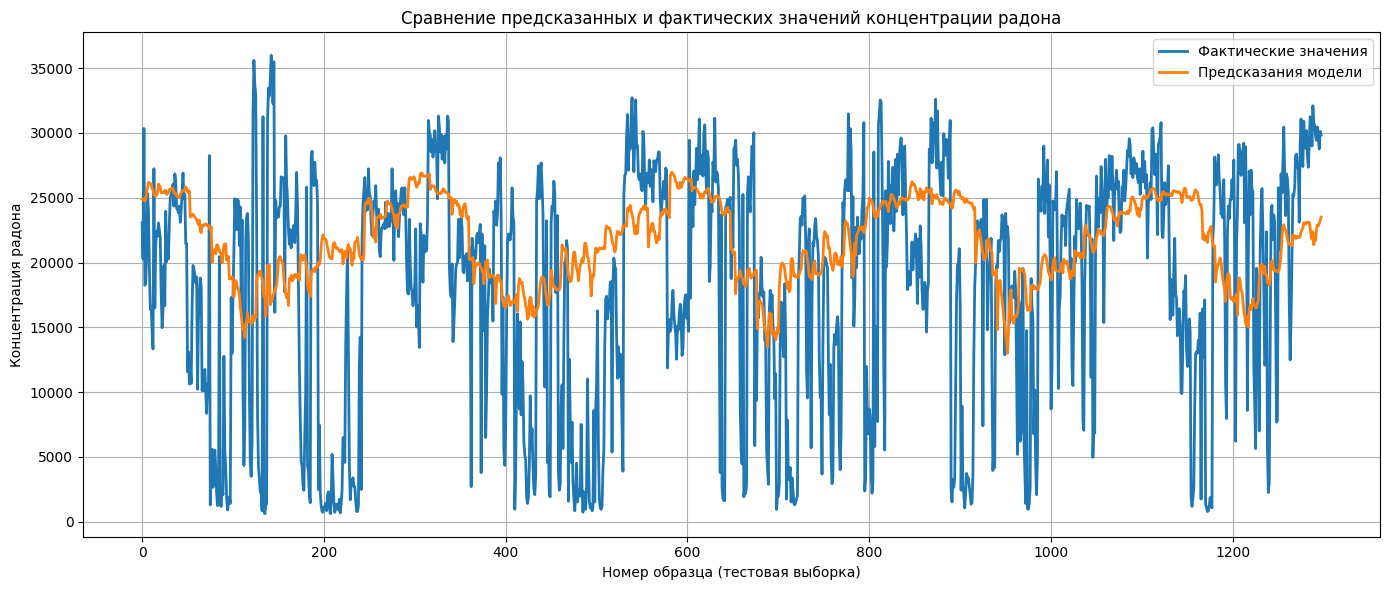

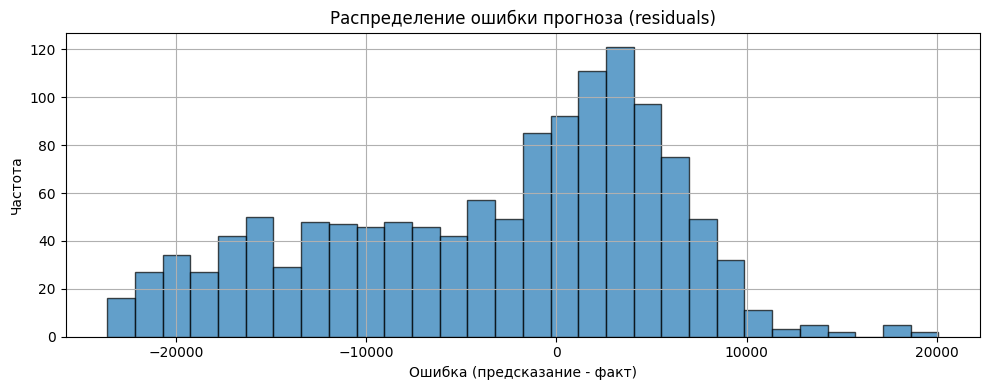

In [10]:
import matplotlib.pyplot as plt

# График сравнения фактических и предсказанных значений на тестовой выборке
plt.figure(figsize=(14, 6))
plt.plot(y_test, label='Фактические значения', linewidth=2)
plt.plot(final_preds, label='Предсказания модели', linewidth=2)
plt.title('Сравнение предсказанных и фактических значений концентрации радона')
plt.xlabel('Номер образца (тестовая выборка)')
plt.ylabel('Концентрация радона')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# График распределения ошибок (остатков) на тестовой выборке
residuals = y_test - final_preds
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title('Распределение ошибки прогноза (residuals)')
plt.xlabel('Ошибка (предсказание - факт)')
plt.ylabel('Частота')
plt.grid(True)
plt.tight_layout()
plt.show()
